In [19]:
data = pd.read_csv("handwritten_digits.csv")

print("Dataset:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)

Dataset:
   Pixel_0  Pixel_1  Pixel_2  Pixel_3  Pixel_4  Pixel_5  Pixel_6  Pixel_7  \
0      0.0      0.0      5.0     13.0      9.0      1.0      0.0      0.0   
1      0.0      0.0      0.0     12.0     13.0      5.0      0.0      0.0   
2      0.0      0.0      0.0      4.0     15.0     12.0      0.0      0.0   
3      0.0      0.0      7.0     15.0     13.0      1.0      0.0      0.0   
4      0.0      0.0      0.0      1.0     11.0      0.0      0.0      0.0   

   Pixel_8  Pixel_9  ...  Pixel_55  Pixel_56  Pixel_57  Pixel_58  Pixel_59  \
0      0.0      0.0  ...       0.0       0.0       0.0       6.0      13.0   
1      0.0      0.0  ...       0.0       0.0       0.0       0.0      11.0   
2      0.0      0.0  ...       0.0       0.0       0.0       0.0       3.0   
3      0.0      8.0  ...       0.0       0.0       0.0       7.0      13.0   
4      0.0      0.0  ...       0.0       0.0       0.0       0.0       2.0   

   Pixel_60  Pixel_61  Pixel_62  Pixel_63  Number  
0      

In [21]:
X = data.drop('Number', axis=1)
y = data['Number']

print("X:")
print(X.head())

print("\nY:")
print(y.head())

X:
   Pixel_0  Pixel_1  Pixel_2  Pixel_3  Pixel_4  Pixel_5  Pixel_6  Pixel_7  \
0      0.0      0.0      5.0     13.0      9.0      1.0      0.0      0.0   
1      0.0      0.0      0.0     12.0     13.0      5.0      0.0      0.0   
2      0.0      0.0      0.0      4.0     15.0     12.0      0.0      0.0   
3      0.0      0.0      7.0     15.0     13.0      1.0      0.0      0.0   
4      0.0      0.0      0.0      1.0     11.0      0.0      0.0      0.0   

   Pixel_8  Pixel_9  ...  Pixel_54  Pixel_55  Pixel_56  Pixel_57  Pixel_58  \
0      0.0      0.0  ...       0.0       0.0       0.0       0.0       6.0   
1      0.0      0.0  ...       0.0       0.0       0.0       0.0       0.0   
2      0.0      0.0  ...       5.0       0.0       0.0       0.0       0.0   
3      0.0      8.0  ...       9.0       0.0       0.0       0.0       7.0   
4      0.0      0.0  ...       0.0       0.0       0.0       0.0       0.0   

   Pixel_59  Pixel_60  Pixel_61  Pixel_62  Pixel_63  
0      13.0

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)

print("X_train:", x_train.shape)
print("Y_train:", y_train.shape)
print("X_test:", x_test.shape)
print("Y_test:", y_test.shape)

X_train: (1437, 64)
Y_train: (1437,)
X_test: (360, 64)
Y_test: (360,)


In [25]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

print("Data standardized successfully!")

Data standardized successfully!


In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

results = []

for k in [1, 2, 3, 4, 5]:

    model = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',
        p=2
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = metrics.accuracy_score(y_test, y_pred)

    results.append(accuracy)

    print("K =", k)
    print("Accuracy =", accuracy)
    print()

K = 1
Accuracy = 0.9777777777777777

K = 2
Accuracy = 0.9805555555555555

K = 3
Accuracy = 0.9777777777777777

K = 4
Accuracy = 0.9777777777777777

K = 5
Accuracy = 0.9777777777777777



In [29]:
model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("KNN model trained successfully!")

KNN model trained successfully!


In [31]:
print("Predicted Values:")
print(y_pred)

print("\nActual Values:")
print(y_test)

Predicted Values:
[5. 2. 5. 5. 5. 3. 2. 2. 3. 5. 9. 8. 7. 3. 1. 1. 5. 7. 0. 4. 5. 9. 0. 2.
 1. 3. 4. 7. 5. 2. 1. 1. 2. 9. 8. 1. 4. 9. 7. 9. 5. 5. 6. 0. 1. 7. 2. 9.
 7. 7. 3. 9. 5. 1. 1. 6. 7. 7. 8. 1. 6. 1. 3. 6. 1. 3. 2. 6. 8. 1. 4. 7.
 1. 6. 0. 0. 5. 1. 3. 5. 1. 6. 4. 0. 4. 7. 5. 7. 8. 3. 7. 8. 5. 1. 1. 7.
 5. 9. 7. 9. 3. 0. 7. 8. 7. 4. 8. 3. 2. 8. 5. 2. 7. 4. 4. 8. 9. 7. 4. 5.
 0. 5. 9. 8. 2. 3. 2. 4. 4. 8. 0. 5. 2. 9. 4. 8. 6. 5. 9. 9. 8. 0. 9. 4.
 3. 8. 7. 5. 5. 3. 3. 5. 1. 0. 8. 7. 2. 8. 4. 1. 0. 0. 3. 6. 4. 7. 7. 0.
 1. 9. 2. 8. 7. 9. 7. 2. 0. 3. 3. 8. 5. 7. 5. 6. 8. 4. 1. 5. 1. 1. 6. 9.
 9. 9. 8. 6. 4. 6. 0. 1. 6. 5. 3. 5. 0. 2. 7. 8. 8. 7. 3. 8. 3. 9. 3. 0.
 9. 6. 0. 4. 0. 3. 5. 0. 4. 3. 5. 8. 8. 9. 2. 5. 0. 8. 3. 7. 4. 3. 7. 9.
 2. 6. 1. 2. 1. 7. 0. 7. 5. 0. 6. 4. 1. 8. 3. 0. 8. 9. 2. 2. 5. 2. 6. 6.
 3. 4. 0. 7. 1. 5. 3. 8. 7. 3. 4. 2. 5. 1. 3. 0. 0. 9. 3. 8. 8. 3. 5. 8.
 6. 6. 2. 6. 7. 5. 3. 1. 5. 7. 5. 4. 5. 2. 6. 2. 0. 6. 0. 7. 2. 5. 8. 8.
 7. 1. 4. 7. 2. 0. 0. 3. 7. 4. 2.

In [33]:
conf_mat = metrics.confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[35  0  0  0  0  0  0  0  0  0]
 [ 0 35  0  0  0  0  0  0  0  0]
 [ 0  0 35  1  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  1  0  0 30  0  0  1  0  0]
 [ 0  0  0  0  0 45  0  0  0  1]
 [ 0  1  0  0  0  0 29  0  0  0]
 [ 0  0  0  0  0  0  0 41  0  1]
 [ 0  0  0  0  0  0  0  0 38  0]
 [ 0  0  0  0  0  2  0  0  0 27]]


In [35]:
accuracy_score = metrics.accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score:", accuracy_score)
print("Accuracy in Percentage:", int(accuracy_score * 100), "%")

Accuracy Score: 0.9777777777777777
Accuracy in Percentage: 97 %


In [37]:
print("Classification Report:")

print(
    metrics.classification_report(
        y_test,
        y_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        35
         1.0       0.95      1.00      0.97        35
         2.0       1.00      0.97      0.99        36
         3.0       0.97      1.00      0.99        37
         4.0       1.00      0.94      0.97        32
         5.0       0.96      0.98      0.97        46
         6.0       1.00      0.97      0.98        30
         7.0       0.98      0.98      0.98        42
         8.0       1.00      1.00      1.00        38
         9.0       0.93      0.93      0.93        29

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



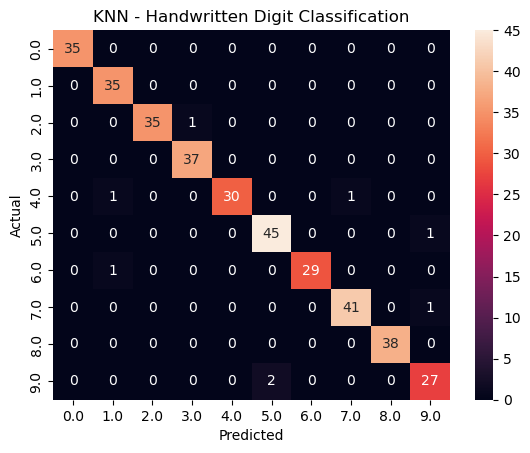

In [39]:
import seaborn as sn
import matplotlib.pyplot as plt

conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)

plt.title("KNN - Handwritten Digit Classification")
plt.show()

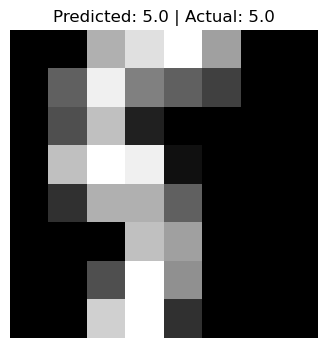

In [43]:
index = 0

original_image = digits.images[y_test.index[index]]

plt.figure(figsize=(4, 4))

plt.imshow(
    original_image,
    cmap='gray'
)

plt.title(
    "Predicted: " + str(y_pred[index]) +
    " | Actual: " + str(y_test.iloc[index])
)

plt.axis('off')
plt.show()